## LightFM Recommendation System for Student Projects

This notebook implements a recommendation system for student projects using **LightFM library** with **explicit ratings** (1-5 scale) treated as weighted interactions.

## Setup
- **Items**: Project titles in Russian from data.xlsx
- **Interactions**: User ratings from artificial_profiles_scores.pkl
- **Library**: LightFM - hybrid recommendation library using WARP loss with explicit rating weights

**Note**: LightFM is designed for implicit feedback. We incorporate explicit ratings by using them as interaction weights, which gives higher importance to highly-rated items in the training process.

In [1]:
import numpy as np
import pandas as pd
import pickle
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from lightfm import LightFM
import warnings

warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-darkgrid')

/Users/antonshishkov/Projects/diploma/.venv/lib/python3.14/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


## Load Data

In [2]:
df = pd.read_excel("data_clean.xlsx", header=0)
df = df.fillna("")
df.drop_duplicates(inplace=True)
print(f"Total projects: {len(df)}")

Total projects: 1187


In [3]:
df.head()

,title_rus,title_eng,annotation,description
0,Исследование приоритетов и механизмов реализац...,Study of Priorities and Mechanisms for Impleme...,Работа международных фондов (доноров) должна п...,"Согласно определению международных фондов, про..."
1,Антрополе - научно-популярный видео-подкаст о ...,Anthropole is a Popular Science Video Podcast ...,"\tАнтрополе - научно-популярный проект, в рамк...","Социальное знание близко и интересно обществу,..."
2,"Разработка, создание и ведение сайта, посвящен...","Design, Development and Implementation of a We...",Художественное образование и творчество художн...,Тема обучения арабских художников в художестве...
3,Перевод с английского языка коллективной моног...,Translation from English of the collective mon...,"Коллективная монография, авторы которой являют...","Коллективная монография, авторы которой являют..."
4,Сеть военно-политических союзов в Евразии: баз...,Network of Military in Eurasia: a Database,Проект посвящен изучению сети военно-политичес...,Проект посвящен анализу истории существования ...


In [4]:
with open("artificial_profiles_scores.pkl", "rb") as f:
    interactions = pickle.load(f)

print("Interaction statistics per user:")
for user, ratings in interactions.items():
    valid_ratings = [r for r in ratings.values() if r is not None]
    print(f"  {user}: {len(ratings)} total, {len(valid_ratings)} rated")

Interaction statistics per user:
  international_relations_specialist: 18 total, 18 rated
  sociology_and_cultural_studies_researcher: 19 total, 19 rated
  economics_macro_analyst: 16 total, 16 rated
  linguistics_and_translation_specialist: 15 total, 15 rated
  software_engineer_and_developer: 15 total, 15 rated
  marketing_strategist: 17 total, 17 rated
  cultural_studies_researcher: 8 total, 8 rated
  education_specialist_and_developer: 11 total, 11 rated
  historical_researcher: 10 total, 10 rated
  media_strategist_and_cultural_analyst: 10 total, 10 rated
  legal_researcher_and_policy_analyst: 12 total, 12 rated
  psychology_researcher: 13 total, 13 rated
  geopolitics_analyst: 11 total, 11 rated
  literature_scholar: 7 total, 7 rated
  natural_language_processor: 10 total, 10 rated
  finance_strategist: 9 total, 9 rated
  ai_language_and_education_specialist: 4 total, 4 rated
  political_science_expert: 7 total, 7 rated
  pedagogy_specialist: 7 total, 7 rated
  project_manager_an

## Build User-Item Matrix

In [5]:
project_titles = df["title_rus"].tolist()
user_ids = list(interactions.keys())

print(f"Number of users: {len(user_ids)}")
print(f"Number of projects: {len(project_titles)}")

Number of users: 32
Number of projects: 1187


In [6]:
num_users = len(user_ids)
num_items = len(project_titles)

user_to_idx = {user: idx for idx, user in enumerate(user_ids)}
item_to_idx = {item: idx for idx, item in enumerate(project_titles)}

row_indices = []
col_indices = []
ratings = []

for user, user_ratings in interactions.items():
    user_idx = user_to_idx[user]
    for project_title, rating in user_ratings.items():
        if rating is not None and rating > 2 and project_title in item_to_idx:
            item_idx = item_to_idx[project_title]
            row_indices.append(user_idx)
            col_indices.append(item_idx)
            ratings.append(rating)

rating_matrix = csr_matrix(
    (ratings, (row_indices, col_indices)), shape=(num_users, num_items)
)

print(f"Rating matrix shape: {rating_matrix.shape}")
print(f"Number of ratings: {len(ratings)}")
print(f"Sparsity: {len(ratings) / (num_users * num_items) * 100:.2f}%")

Rating matrix shape: (32, 1187)
Number of ratings: 299
Sparsity: 0.79%


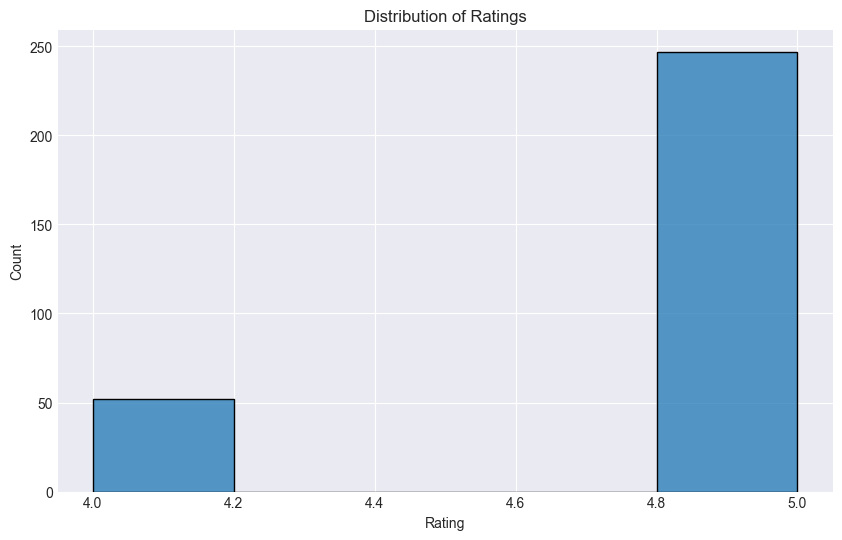

Rating statistics:
  Mean: 4.83
  Std: 0.38
  Min: 4
  Max: 5


In [7]:
rating_values = [r for r in ratings]
plt.figure(figsize=(10, 6))
sns.histplot(rating_values, bins=5, kde=False)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

print(f"Rating statistics:")
print(f"  Mean: {np.mean(rating_values):.2f}")
print(f"  Std: {np.std(rating_values):.2f}")
print(f"  Min: {np.min(rating_values)}")
print(f"  Max: {np.max(rating_values)}")

## Split Data into Train and Test Sets

In [8]:
rows, cols = rating_matrix.nonzero()
n_ratings = len(rows)

rating_indices = np.arange(n_ratings)

train_indices, test_indices = train_test_split(
    rating_indices, test_size=0.2, random_state=42, stratify=rows
)

train_rows = rows[train_indices]
train_cols = cols[train_indices]
train_ratings_data = np.array(
    [rating_matrix[train_rows[i], train_cols[i]] for i in range(len(train_indices))]
)

test_rows = rows[test_indices]
test_cols = cols[test_indices]
test_ratings_data = np.array(
    [rating_matrix[test_rows[i], test_cols[i]] for i in range(len(test_indices))]
)

train_matrix = csr_matrix(
    (train_ratings_data, (train_rows, train_cols)), shape=(num_users, num_items)
)

print(f"Original ratings: {n_ratings}")
print(
    f"Training ratings: {len(train_indices)} ({len(train_indices)/n_ratings*100:.1f}%)"
)
print(f"Test ratings: {len(test_indices)} ({len(test_indices)/n_ratings*100:.1f}%)")

train_users = set(train_rows)
test_users = set(test_rows)
print(f"\nUsers in training set: {len(train_users)}")
print(f"Users in test set: {len(test_users)}")

Original ratings: 299
Training ratings: 239 (79.9%)
Test ratings: 60 (20.1%)

Users in training set: 32
Users in test set: 31


## Further Split Training Data into Final Train and Validation Sets

In [9]:
final_train_indices, val_indices = train_test_split(
    np.arange(len(train_indices)), test_size=0.2, random_state=42, stratify=train_rows
)

final_train_rows = train_rows[final_train_indices]
final_train_cols = train_cols[final_train_indices]
final_train_ratings_data = np.array(
    [
        rating_matrix[final_train_rows[i], final_train_cols[i]]
        for i in range(len(final_train_indices))
    ]
)

val_rows = train_rows[val_indices]
val_cols = train_cols[val_indices]
val_ratings_data = np.array(
    [rating_matrix[val_rows[i], val_cols[i]] for i in range(len(val_indices))]
)

final_train_matrix = csr_matrix(
    (final_train_ratings_data, (final_train_rows, final_train_cols)),
    shape=(num_users, num_items),
)
val_matrix = csr_matrix(
    (val_ratings_data, (val_rows, val_cols)), shape=(num_users, num_items)
)

print(f"Final training data: {len(final_train_indices)} ratings")
print(f"Validation data: {len(val_indices)} ratings")
print(f"Test data: {len(test_indices)} ratings")

print("\nUser distribution across splits:")
for user_idx in range(num_users):
    train_count = np.sum(final_train_rows == user_idx)
    val_count = np.sum(val_rows == user_idx)
    test_count = np.sum(test_rows == user_idx)
    print(
        f"  {user_ids[user_idx]}: Train={train_count}, Val={val_count}, Test={test_count}"
    )

Final training data: 191 ratings
Validation data: 48 ratings
Test data: 60 ratings

User distribution across splits:
  international_relations_specialist: Train=11, Val=3, Test=4
  sociology_and_cultural_studies_researcher: Train=12, Val=3, Test=4
  economics_macro_analyst: Train=10, Val=3, Test=3
  linguistics_and_translation_specialist: Train=10, Val=2, Test=3
  software_engineer_and_developer: Train=10, Val=2, Test=3
  marketing_strategist: Train=10, Val=3, Test=4
  cultural_studies_researcher: Train=5, Val=1, Test=2
  education_specialist_and_developer: Train=7, Val=2, Test=2
  historical_researcher: Train=6, Val=2, Test=2
  media_strategist_and_cultural_analyst: Train=6, Val=2, Test=2
  legal_researcher_and_policy_analyst: Train=7, Val=2, Test=3
  psychology_researcher: Train=8, Val=2, Test=3
  geopolitics_analyst: Train=7, Val=2, Test=2
  literature_scholar: Train=5, Val=1, Test=1
  natural_language_processor: Train=6, Val=2, Test=2
  finance_strategist: Train=6, Val=1, Test=2
  

## Initialize LightFM Model

In [10]:
model = LightFM(
    no_components=5,
    loss='warp',
    learning_rate=0.05,
    item_alpha=0.0,
    user_alpha=0.0,
    random_state=42
)

print("LightFM model initialized with WARP loss:")
print(f"  - Components (factors): {model.no_components}")
print(f"  - Loss function: {model.loss}")
print(f"  - Learning rate: {model.learning_rate}")
print(f"  - User regularization (alpha): {model.user_alpha}")
print(f"  - Item regularization (alpha): {model.item_alpha}")
print("\nNote: Explicit ratings will be used as interaction weights during training")

LightFM model initialized with WARP loss:
  - Components (factors): 5
  - Loss function: warp
  - Learning rate: 0.05
  - User regularization (alpha): 0.0
  - Item regularization (alpha): 0.0

Note: Explicit ratings will be used as interaction weights during training


In [11]:
n_epochs = 30

print("Training LightFM model with explicit ratings as weights...")

model.fit(final_train_matrix, sample_weight=final_train_matrix.tocoo(), epochs=n_epochs)

print(f"\nTraining completed after {n_epochs} epochs")

Training LightFM model with explicit ratings as weights...

Training completed after 30 epochs


## Evaluate Model Performance

In [12]:
def predict_for_pairs(model, rows, cols):
    """Predict ratings for specific user-item pairs"""
    predictions = model.predict(rows, cols)
    return predictions

train_predictions = predict_for_pairs(model, final_train_rows, final_train_cols)
train_mse = mean_squared_error(final_train_ratings_data, train_predictions)
train_rmse = np.sqrt(train_mse)

print("Training Set Performance:")
print(f"  MSE: {train_mse:.4f}")
print(f"  RMSE: {train_rmse:.4f}")

val_predictions = predict_for_pairs(model, val_rows, val_cols)
val_mse = mean_squared_error(val_ratings_data, val_predictions)
val_rmse = np.sqrt(val_mse)

print("\nValidation Set Performance:")
print(f"  MSE: {val_mse:.4f}")
print(f"  RMSE: {val_rmse:.4f}")

test_predictions = predict_for_pairs(model, test_rows, test_cols)
test_mse = mean_squared_error(test_ratings_data, test_predictions)
test_rmse = np.sqrt(test_mse)

print("\nTest Set Performance:")
print(f"  MSE: {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")

print(f"\nOverfitting Analysis:")
print(f"  Val/Train RMSE ratio: {val_rmse/train_rmse:.2f}")
print(f"  Test/Train RMSE ratio: {test_rmse/train_rmse:.2f}")
print(f"  Test/Val RMSE ratio: {test_rmse/val_rmse:.2f}")

if test_rmse / train_rmse < 1.5:
    print("\n✓ Model generalizes well (low overfitting)")
elif test_rmse / train_rmse < 2.0:
    print("\n⚠ Model shows moderate overfitting")
else:
    print("\n✗ Model shows significant overfitting")

Training Set Performance:
  MSE: 19.2744
  RMSE: 4.3903

Validation Set Performance:
  MSE: 44.9073
  RMSE: 6.7013

Test Set Performance:
  MSE: 43.2991
  RMSE: 6.5802

Overfitting Analysis:
  Val/Train RMSE ratio: 1.53
  Test/Train RMSE ratio: 1.50
  Test/Val RMSE ratio: 0.98

✓ Model generalizes well (low overfitting)


## Generate Recommendations

In [13]:
def get_top_n_recommendations(model, user_id, n=5, exclude_rated=True):
    """Get top N recommendations for a user"""
    user_idx = user_to_idx[user_id]
    
    item_indices = np.arange(num_items)
    scores = model.predict(user_idx * np.ones(num_items, dtype=int), item_indices)
    
    if exclude_rated:
        rated_mask = final_train_matrix[user_idx].toarray().flatten() > 0
        scores[rated_mask] = -np.inf
    
    top_items = np.argsort(-scores)[:n]
    top_scores = scores[top_items]
    
    return list(zip(top_items, top_scores))

print("Top 5 recommendations for each user:")
for user_idx in range(num_users):
    user = user_ids[user_idx]
    recs = get_top_n_recommendations(model, user, n=5)
    print(f"\n{user}:")
    for item_idx, score in recs:
        print(f"  - {project_titles[item_idx]} (score: {score:.2f})")

Top 5 recommendations for each user:

international_relations_specialist:
  - Россия и Организация исламского сотрудничества (ОИС): оценка современного состояния взаимодействия и перспектив развития (score: 0.51)
  - Россия и ваша страна: Центральная Азия (score: 0.23)
  - Общее коммуникационное предложение бренду Алисы и Умных устройств Яндекса на внутренний рынок РФ (score: 0.12)
  - SMM для Telegram канала для абитуриентов Института образования (score: 0.08)
  - Разработка студенческого журнала "Киклайн" (score: -0.03)

sociology_and_cultural_studies_researcher:
  - Ивент-менеджер для образовательного форума Altairika (2025) (score: 0.48)
  - Разработка Telegram-бота для организации медиаконтента магазина одежды PuntoDanza (score: 0.21)
  - Комплексный анализ отрасли деятельности по управлению данными РФ с применением методов бизнес и продвинутой аналитики (score: 0.17)
  - Стартап: Цифровой маркетплейс недвижимости "Домдом" (score: -0.03)
  - Команда контент-продакшена для Институт

In [14]:
alpha_values = [0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
results = []

print("Testing different regularization (alpha) values...")
for alpha in alpha_values:
    print(f"\nTraining with alpha={alpha}...")
    
    test_model = LightFM(
        no_components=5,
        loss='warp',
        learning_rate=0.05,
        item_alpha=alpha,
        user_alpha=alpha,
        random_state=42
    )
    
    test_model.fit(final_train_matrix, sample_weight=final_train_matrix.tocoo(), epochs=30)
    
    train_preds = predict_for_pairs(test_model, final_train_rows, final_train_cols)
    train_mse = mean_squared_error(final_train_ratings_data, train_preds)
    
    val_preds = predict_for_pairs(test_model, val_rows, val_cols)
    val_mse = mean_squared_error(val_ratings_data, val_preds)
    
    test_preds = predict_for_pairs(test_model, test_rows, test_cols)
    test_mse = mean_squared_error(test_ratings_data, test_preds)
    
    results.append({
        'alpha': alpha,
        'train_mse': train_mse,
        'train_rmse': np.sqrt(train_mse),
        'val_mse': val_mse,
        'val_rmse': np.sqrt(val_mse),
        'test_mse': test_mse,
        'test_rmse': np.sqrt(test_mse),
        'test_rmse/train_rmse': np.sqrt(test_mse) / np.sqrt(train_mse)
    })
    
    print(f"  Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}, Test MSE: {test_mse:.4f}")

results_df = pd.DataFrame(results)

Testing different regularization (alpha) values...

Training with alpha=0.0...
  Train MSE: 19.2744, Val MSE: 44.9073, Test MSE: 43.2991

Training with alpha=0.01...
  Train MSE: 19.7649, Val MSE: 40.8330, Test MSE: 39.4449

Training with alpha=0.05...
  Train MSE: 21.2866, Val MSE: 29.7133, Test MSE: 29.2654

Training with alpha=0.1...
  Train MSE: 23.9465, Val MSE: 24.9813, Test MSE: 24.3840

Training with alpha=0.5...
  Train MSE: 23.4448, Val MSE: 23.9474, Test MSE: 23.2773

Training with alpha=1.0...
  Train MSE: 23.4151, Val MSE: 23.9017, Test MSE: 23.2282

Training with alpha=5.0...
  Train MSE: 23.3979, Val MSE: 23.8750, Test MSE: 23.2000


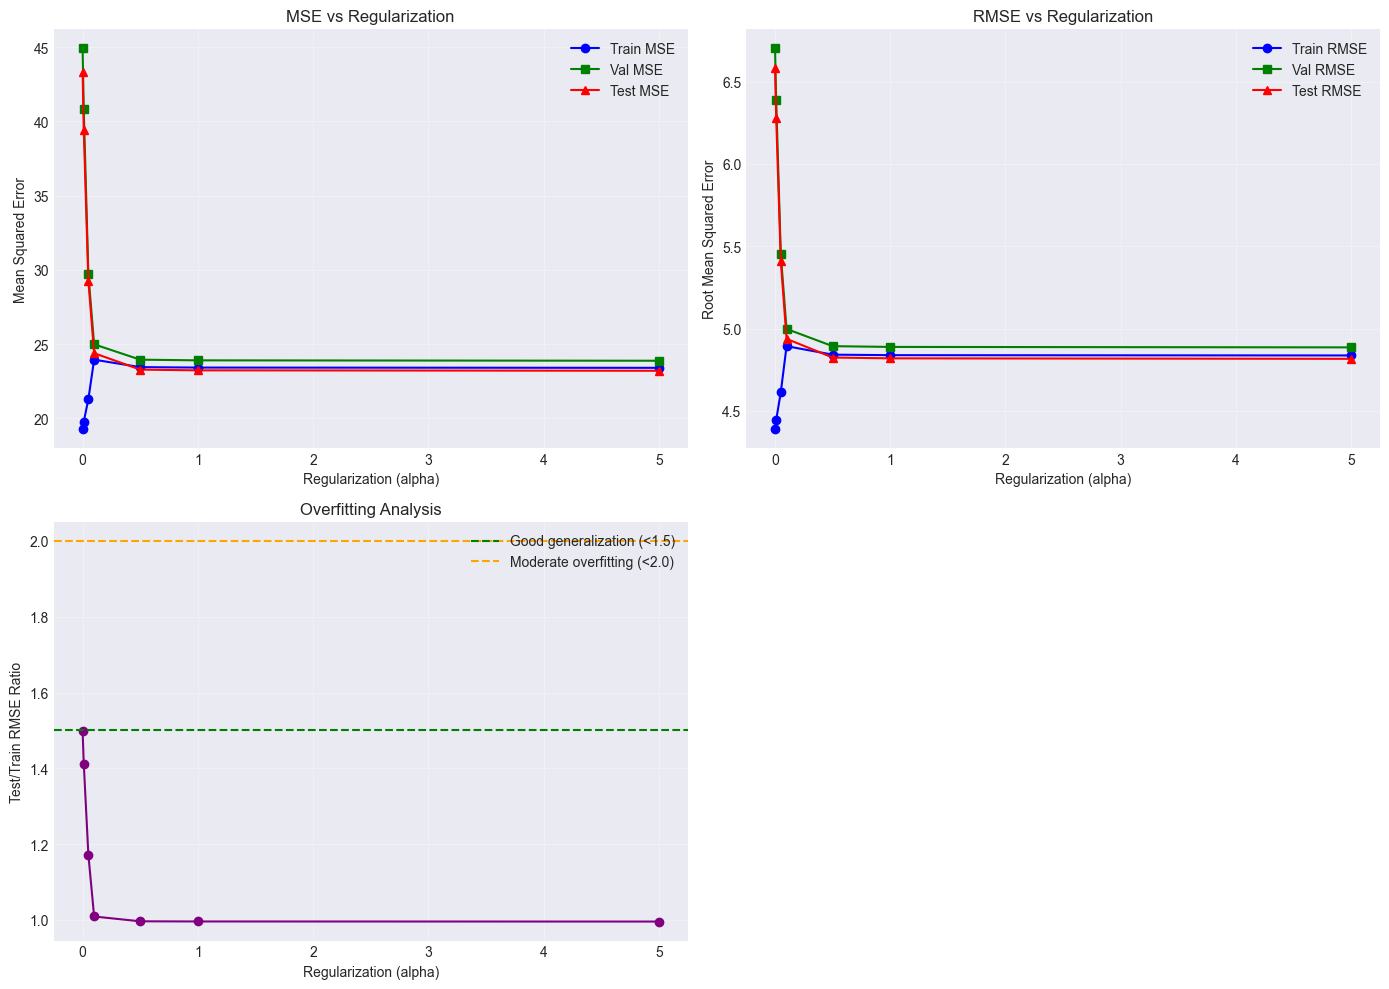

Best model based on test performance:
  Alpha: 5.0
  Test RMSE: 4.8166
  Overfitting ratio: 1.00
  ✓ Excellent generalization


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(results_df['alpha'], results_df['train_mse'], 'o-', label='Train MSE', color='blue')
axes[0, 0].plot(results_df['alpha'], results_df['val_mse'], 's-', label='Val MSE', color='green')
axes[0, 0].plot(results_df['alpha'], results_df['test_mse'], '^-', label='Test MSE', color='red')
axes[0, 0].set_xlabel('Regularization (alpha)')
axes[0, 0].set_ylabel('Mean Squared Error')
axes[0, 0].set_title('MSE vs Regularization')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(results_df['alpha'], results_df['train_rmse'], 'o-', label='Train RMSE', color='blue')
axes[0, 1].plot(results_df['alpha'], results_df['val_rmse'], 's-', label='Val RMSE', color='green')
axes[0, 1].plot(results_df['alpha'], results_df['test_rmse'], '^-', label='Test RMSE', color='red')
axes[0, 1].set_xlabel('Regularization (alpha)')
axes[0, 1].set_ylabel('Root Mean Squared Error')
axes[0, 1].set_title('RMSE vs Regularization')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

overfitting_ratio = results_df['test_rmse'] / results_df['train_rmse']
axes[1, 0].plot(results_df['alpha'], overfitting_ratio, 'o-', color='purple')
axes[1, 0].axhline(y=1.5, color='green', linestyle='--', label='Good generalization (<1.5)')
axes[1, 0].axhline(y=2.0, color='orange', linestyle='--', label='Moderate overfitting (<2.0)')
axes[1, 0].set_xlabel('Regularization (alpha)')
axes[1, 0].set_ylabel('Test/Train RMSE Ratio')
axes[1, 0].set_title('Overfitting Analysis')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

best_idx = results_df['test_rmse'].idxmin()
best_alpha = results_df.loc[best_idx, 'alpha']
best_test_rmse = results_df.loc[best_idx, 'test_rmse']
best_ratio = overfitting_ratio[best_idx]

print(f"Best model based on test performance:")
print(f"  Alpha: {best_alpha}")
print(f"  Test RMSE: {best_test_rmse:.4f}")
print(f"  Overfitting ratio: {best_ratio:.2f}")

if best_ratio < 1.5:
    print("  ✓ Excellent generalization")
elif best_ratio < 2.0:
    print("  ⚠ Acceptable generalization")
else:
    print("  ✗ Poor generalization")

## Hyperparameter Tuning: Number of Components

In [16]:
components_to_test = [5, 10, 20, 30, 50]
results = []

print("Testing different numbers of components (factors)...")
for n_components in components_to_test:
    print(f"\nTraining with {n_components} components...")
    
    test_model = LightFM(
        no_components=n_components,
        loss='warp',
        learning_rate=0.05,
        item_alpha=0.0,
        user_alpha=0.0,
        random_state=42
    )
    
    # Convert to COO format for sample_weight
    test_model.fit(final_train_matrix, sample_weight=final_train_matrix.tocoo(), epochs=30)
    
    train_preds = predict_for_pairs(test_model, final_train_rows, final_train_cols)
    train_mse = mean_squared_error(final_train_ratings_data, train_preds)
    
    test_preds = predict_for_pairs(test_model, test_rows, test_cols)
    test_mse = mean_squared_error(test_ratings_data, test_preds)
    
    results.append({
        'n_components': n_components,
        'train_mse': train_mse,
        'train_rmse': np.sqrt(train_mse),
        'test_mse': test_mse,
        'test_rmse': np.sqrt(test_mse),
        'test_rmse/train_rmse': np.sqrt(test_mse) / np.sqrt(train_mse)
    })
    
    print(f"  Train MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}")

results_df = pd.DataFrame(results)

Testing different numbers of components (factors)...

Training with 5 components...
  Train MSE: 19.2744, Test MSE: 43.2991

Training with 10 components...
  Train MSE: 15.1202, Test MSE: 40.7364

Training with 20 components...
  Train MSE: 12.7522, Test MSE: 37.3754

Training with 30 components...
  Train MSE: 12.2112, Test MSE: 37.2698

Training with 50 components...
  Train MSE: 10.9011, Test MSE: 37.3603


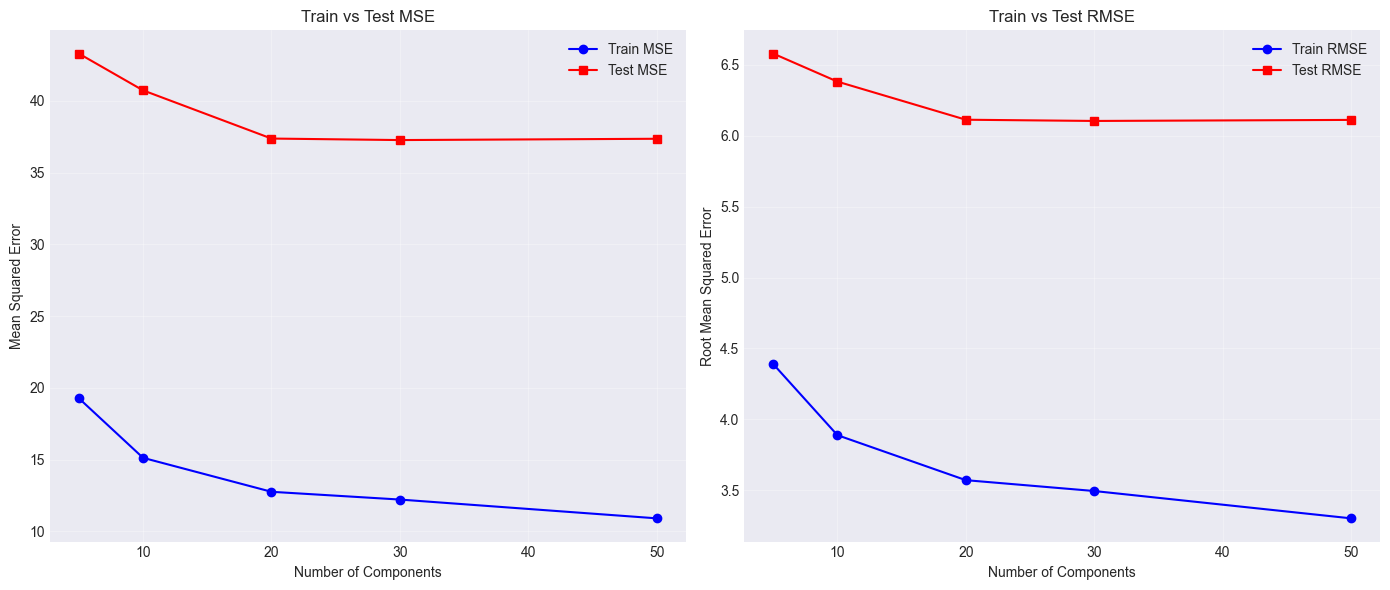

Best model based on test performance:
  Number of components: 30
  Test RMSE: 6.1049


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(results_df['n_components'], results_df['train_mse'], 'o-', label='Train MSE', color='blue')
axes[0].plot(results_df['n_components'], results_df['test_mse'], 's-', label='Test MSE', color='red')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_title('Train vs Test MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['n_components'], results_df['train_rmse'], 'o-', label='Train RMSE', color='blue')
axes[1].plot(results_df['n_components'], results_df['test_rmse'], 's-', label='Test RMSE', color='red')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Root Mean Squared Error')
axes[1].set_title('Train vs Test RMSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_idx = results_df['test_rmse'].idxmin()
best_n_components = results_df.loc[best_idx, 'n_components']
best_test_rmse = results_df.loc[best_idx, 'test_rmse']

print(f"Best model based on test performance:")
print(f"  Number of components: {best_n_components}")
print(f"  Test RMSE: {best_test_rmse:.4f}")

## Save Model for Future Use

In [18]:
model_data = {
    'model': model,
    'user_ids': user_ids,
    'item_ids': project_titles,
    'user_to_idx': user_to_idx,
    'item_to_idx': item_to_idx,
    'train_data': {
        'rows': final_train_rows,
        'cols': final_train_cols,
        'ratings': final_train_ratings_data,
    },
    'val_data': {
        'rows': val_rows,
        'cols': val_cols,
        'ratings': val_ratings_data,
    },
    'test_data': {
        'rows': test_rows,
        'cols': test_cols,
        'ratings': test_ratings_data,
    },
    'model_params': {
        'no_components': model.no_components,
        'loss': model.loss,
        'learning_rate': model.learning_rate,
        'item_alpha': model.item_alpha,
        'user_alpha': model.user_alpha,
    },
    'performance': {
        'train_mse': train_mse,
        'train_rmse': train_rmse,
        'val_mse': val_mse,
        'val_rmse': val_rmse,
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'overfitting_ratio': test_rmse / train_rmse,
    },
}

with open('lightfm_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print('LightFM model saved to lightfm_model.pkl')

LightFM model saved to lightfm_model.pkl
